# Code calibration using normalized reliability

Assess candidate code factors over representative load ratios using the normalized reliability approach. The workflow is: specify probability models and characteristic values, generate code-conforming designs, evaluate reliability, and compare the candidates against a target.

**Before you start:** the introductory reliability and load-combination tutorials. This example uses the core PySTRA installation.

## Problem and assumptions

$R$, $G$, $P$ and $Q$ are normalized resistance, self-weight, other permanent load and variable load. Their means are one in this example; resistance and load model-error factors have separately specified means and variability.

The load ratios are $a_g=G/(G+P)$ and $a_q=Q/(G+P+Q)$, interpreted through the representative mean load contributions. Thus $a_g=1$ means all permanent load is self-weight, while $a_q=1$ means the demand is entirely variable load.

For each candidate factor set, solve the code equation for the resistance scale $z$:

$$\phi z r_k=(1-a_q)\left[a_g\gamma_g g_k+(1-a_g)\gamma_p p_k\right]+a_q\gamma_q q_k.$$

Then assess the resulting design with

$$g=\omega_R z R-\omega_S\left[(1-a_q)\left(a_gG+(1-a_g)P\right)+a_qQ\right].$$

Here $r_k,g_k,p_k,q_k$ are the normalized characteristic values. The model errors $\omega_R$ and $\omega_S$ multiply resistance and demand respectively. This is a dimensionless calibration study; the factor values and target below are illustrative inputs, not a prescribed design-code recommendation.

## Specify the model and candidate factors

`NormalizedReliabilityModel` holds the probability model and characteristic values. `CodeFactors` describes one candidate code rule. Keeping those inputs separate makes comparisons between factor sets explicit.

In [1]:
import pystra as ra
import numpy as np
from dataclasses import replace

model = ra.calibration.NormalizedReliabilityModel(
    resistance_error=ra.Normal("wR", 1.06, 1.06 * 0.05),
    load_error=ra.Lognormal("wS", 1.0, 0.10),
    resistance=ra.Lognormal("R", 1.0, 0.08),
    dead_load=ra.Normal("G", 1.0, 0.08),
    permanent_load=ra.Normal("P", 1.0, 0.10),
    live_load=ra.Normal("Q", 1.0, 0.02),
    nominal_values=ra.calibration.NominalValues(
        resistance=1 / 1.08,
        dead_load=1 / 1.03,
        permanent_load=1.0,
        live_load=1 / 0.75,
    ),
)
current_factors = ra.calibration.CodeFactors(phi=0.80, gamma_g=1.2, gamma_p=1.7, gamma_q=1.6)
proposed_factors = replace(current_factors, gamma_p=1.5, gamma_q=1.4)


## Evaluate code-conforming designs

`CodeCalibration` evaluates the load-ratio grid using the normalized reliability model. Each run returns the resistance scales, FORM results and margins against the target. Dependence can be supplied through `NormalizedReliabilityModel.copula`; this example uses independent inputs.

In [2]:
study = ra.calibration.CodeCalibration(
    live_load_ratios=np.arange(0.1, 1.1, 0.1),
    dead_load_ratios=np.arange(0.1, 1.1, 0.1),
)
current_result = study.run(model, current_factors, target_beta=4.7)
proposed_result = study.run(model, proposed_factors, target_beta=4.7)
assert current_result.converged and proposed_result.converged
current_result.to_frame().head()


,live_load_ratio,dead_load_ratio,design_value,failure_probability,beta,converged,status,message,method,target_margin
0,0.1,0.1,2.288503,7.290360e-09,5.666425,True,converged,Converged,FORM,0.966425
1,0.2,0.1,2.354225,1.183257e-09,5.970415,True,converged,Converged,FORM,1.270415
2,0.3,0.1,2.419947,1.789648e-10,6.271351,True,converged,Converged,FORM,1.571351
3,0.4,0.1,2.485669,2.575168e-11,6.566524,True,converged,Converged,FORM,1.866524
4,0.5,0.1,2.551391,3.631771e-12,6.852372,True,converged,Converged,FORM,2.152372


## Compare reliability across the load ratios

The envelope spans the self-weight shares at each variable-load ratio. The dotted curve corresponds to the smallest self-weight share. `plot_calibration` consumes the completed results and identifies failed studies rather than hiding them.

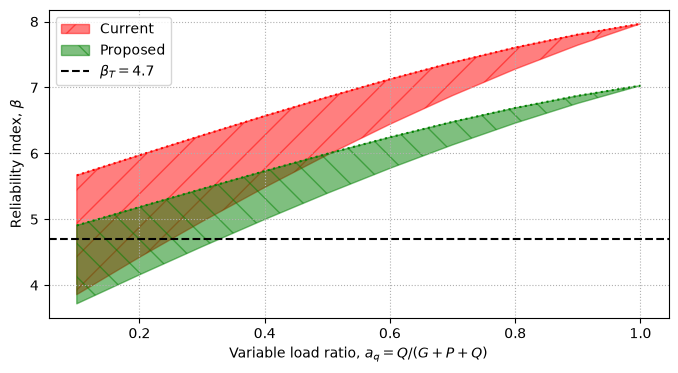

In [3]:
results = {"Current": current_result, "Proposed": proposed_result}
fig, ax = ra.calibration.plot_calibration(
    results, target_beta=4.7, colors={"Current": "r", "Proposed": "g"}
)


**Figure.** Current and proposed factor sets produce different reliability envelopes over live-load ratio. Compare each envelope with the target and inspect the full dead-load-ratio range.

Optional annotation ranges belong to the plotting call:

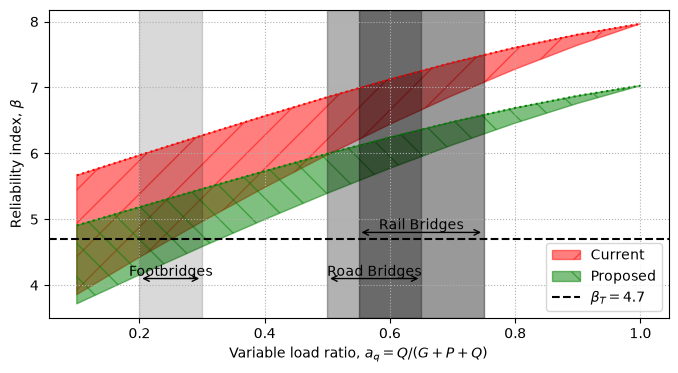

In [4]:
ranges = [
    {"xl": 0.2, "xu": 0.3, "ytext": 4.1, "text": "Footbridges", "alpha": 0.15},
    {"xl": 0.5, "xu": 0.65, "ytext": 4.1, "text": "Road Bridges", "alpha": 0.3},
    {"xl": 0.55, "xu": 0.75, "ytext": 4.8, "text": "Rail Bridges", "alpha": 0.4},
]
fig, ax = ra.calibration.plot_calibration(
    results, target_beta=4.7, ranges=ranges, colors={"Current": "r", "Proposed": "g"}
)


**Figure.** The same reliability comparison includes illustrative application ranges for footbridges, road bridges and rail bridges; these ranges are assumptions for the example.

## Interpretation

Reducing load factors changes the resistance required by the code equation and therefore the achieved reliability. Inspect the per-case target margins before choosing a factor set. This example evaluates specified candidates; it does not automatically optimize the factors.

[Calibrating partial and combination factors](ex_factor_calibration.ipynb) demonstrates factor derivation and verification within the same code-calibration workflow. See [code-calibration theory](../theory/code_calibration.rst) for the normalized formulation and its relationship to those operations.

Study results retain every grid point. Inspect `current_result.converged` and the status/message columns of `current_result.to_frame()` before comparing factor sets. An alternative reliability method or external adapter can be supplied with `evaluator=`; see the [calibration guide](../guides/calibration.rst).


**Continue:** [User guide](../guides/calibration.rst) · [API reference](../api/calibration.rst) · [Theory](../theory/code_calibration.rst)